# 01 - Diagnóstico y selección S1→S2

Cada hallazgo sigue el patrón: pregunta → SQL vía DuckDB → gráfico → conclusión.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATASET = ROOT / 'data' / 'GTM-Engineer-BC-Dataset.xlsx'
TOP50 = ROOT / 'analysis' / 'top50.csv'
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 5)

universo = pd.read_excel(DATASET, sheet_name='universo_potencial')
xsell = pd.read_excel(DATASET, sheet_name='bnpl_xsell_sample')
funnel = pd.read_excel(DATASET, sheet_name='funnel_snapshot')
top50 = pd.read_csv(TOP50)

con = duckdb.connect()
con.register('universo', universo)
con.register('xsell', xsell)
con.register('funnel_snapshot', funnel)
con.register('top50', top50)
print({'universo': universo.shape, 'xsell': xsell.shape, 'funnel': funnel.shape, 'top50': top50.shape})

{'universo': (5000, 16), 'xsell': (2500, 13), 'funnel': (150, 13), 'top50': (50, 15)}


## 1. ¿Por qué atacar S1→S2?

In [2]:
sql_stage_touch = '''
SELECT
  stage,
  COUNT(*) AS n_leads,
  ROUND(AVG(days_since_last_touch), 1) AS avg_days_since_last_touch,
  ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct_pipeline
FROM funnel_snapshot
GROUP BY stage
ORDER BY
  CASE stage
    WHEN 'S1_Prospect' THEN 1 WHEN 'S2_Contacted' THEN 2 WHEN 'S3_Qualified' THEN 3
    WHEN 'S4_Demo_done' THEN 4 WHEN 'S5_Negotiation' THEN 5 WHEN 'S6_Contract_signed' THEN 6
    WHEN 'S7_Onboarding' THEN 7 WHEN 'S8_Live' THEN 8 ELSE 99 END
'''
stage_touch = con.sql(sql_stage_touch).df()
stage_touch

,stage,n_leads,avg_days_since_last_touch,pct_pipeline
0,S1_Prospect,47,36.3,31.3
1,S2_Contacted,36,8.3,24.0
2,S3_Qualified,25,7.2,16.7
3,S4_Demo_done,16,2.8,10.7
4,S5_Negotiation,13,3.8,8.7
5,S6_Contract_signed,5,3.0,3.3
6,S7_Onboarding,3,3.3,2.0
7,S8_Live,2,5.0,1.3
8,X_Lost,3,32.3,2.0


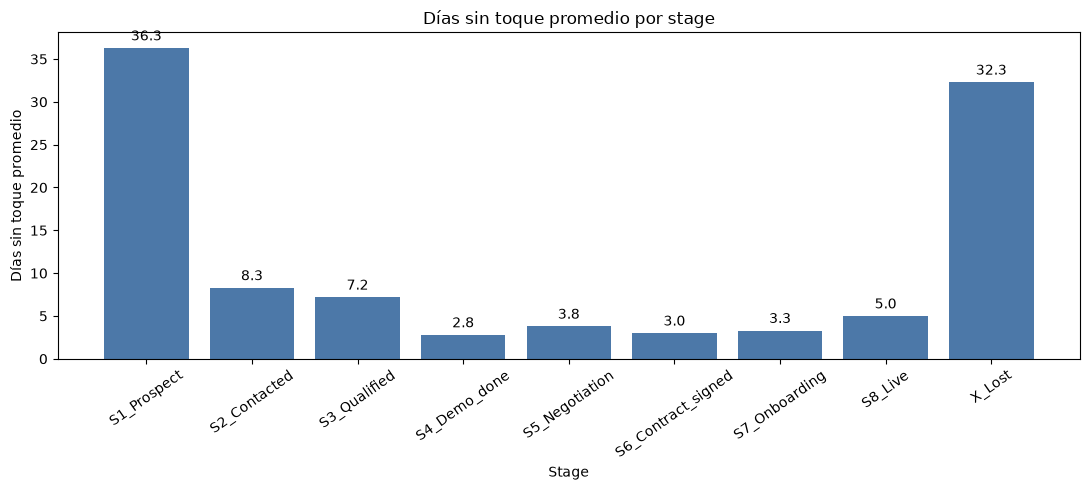

S1 representa 31.3% del pipeline (47 de 150 leads) y acumula 36.3 días sin toque promedio.


In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(stage_touch['stage'], stage_touch['avg_days_since_last_touch'], color='#4c78a8')
ax.set_title('Días sin toque promedio por stage')
ax.set_xlabel('Stage')
ax.set_ylabel('Días sin toque promedio')
ax.tick_params(axis='x', rotation=35)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)
plt.tight_layout()
plt.show()

s1 = stage_touch.loc[stage_touch['stage'].eq('S1_Prospect')].iloc[0]
print(f"S1 representa {s1.pct_pipeline:.1f}% del pipeline ({int(s1.n_leads)} de {len(funnel)} leads) y acumula {s1.avg_days_since_last_touch:.1f} días sin toque promedio.")

**Conclusión:** S1→S2 es el cuello operativo más accionable: concentra una parte material del pipeline antes del primer contacto, donde una motion automatizada puede aumentar cadencia sin esperar cierres comerciales.

## 2. ¿Por qué BNPL x-sell como lead source?

In [4]:
sql_cvr = '''
WITH base AS (
  SELECT
    source,
    COUNT(*) AS n,
    SUM(CASE WHEN stage IN ('S3_Qualified','S4_Demo_done','S5_Negotiation','S6_Contract_signed','S7_Onboarding','S8_Live') THEN 1 ELSE 0 END) AS s3_plus
  FROM funnel_snapshot
  WHERE source IN ('BNPL_xsell', 'Outbound_cold', 'Referral')
  GROUP BY source
)
SELECT
  source,
  n,
  s3_plus,
  ROUND(100.0 * s3_plus / n, 1) AS cvr_s3_plus_pct
FROM base
ORDER BY cvr_s3_plus_pct DESC
'''
cvr = con.sql(sql_cvr).df()
cvr['label'] = cvr.apply(lambda r: f"{r.cvr_s3_plus_pct:.1f}%\nn={int(r.n)}", axis=1)
cvr

,source,n,s3_plus,cvr_s3_plus_pct,label
0,BNPL_xsell,70,33.0,47.1,47.1%\nn=70
1,Outbound_cold,21,7.0,33.3,33.3%\nn=21
2,Referral,16,4.0,25.0,25.0%\nn=16


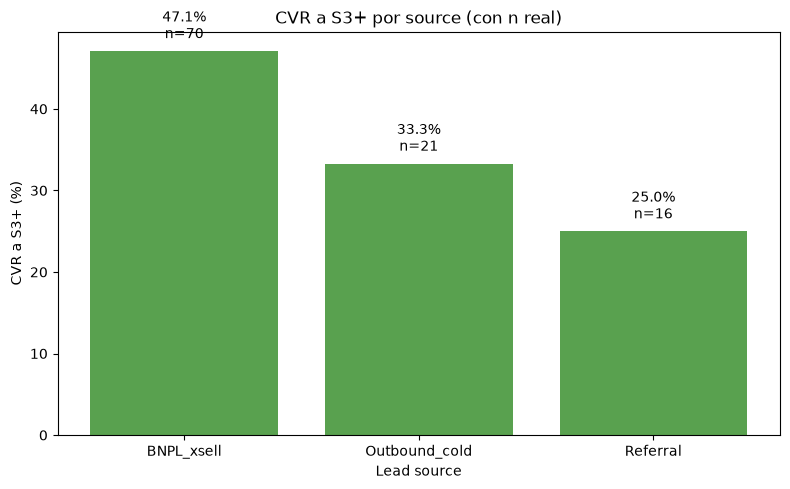

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(cvr['source'], cvr['cvr_s3_plus_pct'], color='#59a14f')
ax.set_title('CVR a S3+ por source (con n real)')
ax.set_xlabel('Lead source')
ax.set_ylabel('CVR a S3+ (%)')
for i, row in cvr.reset_index(drop=True).iterrows():
    ax.text(i, row.cvr_s3_plus_pct + 1, row.label, ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Conclusión:** BNPL_xsell combina relación previa y mejor señal de intención; el conteo `n` se muestra explícitamente porque la comparación es direccional sobre muestra pequeña.

## 3. ¿Por qué excluir Grandes Superficies?

In [6]:
sql_gs = '''
SELECT
  category,
  COUNT(*) AS n_brands,
  ROUND(SUM(gmv_cop_millions_12m), 0) AS gmv_cop_millions_12m,
  ROUND(100.0 * SUM(gmv_cop_millions_12m) / (SELECT SUM(gmv_cop_millions_12m) FROM universo), 1) AS pct_total_gmv
FROM universo
WHERE category = 'Grandes Superficies'
GROUP BY category
'''
gs = con.sql(sql_gs).df()
gs

,category,n_brands,gmv_cop_millions_12m,pct_total_gmv
0,Grandes Superficies,3,542464.0,10.2


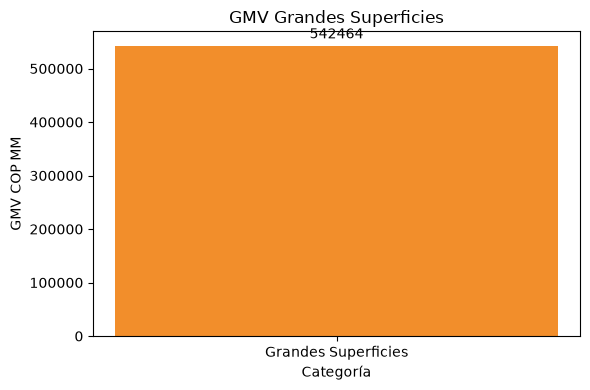

Grandes Superficies son 3 megacuentas y representan COP 542,464 MM (10.2% del GMV total del universo).


In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(gs['category'], gs['gmv_cop_millions_12m'], color='#f28e2b')
ax.set_title('GMV Grandes Superficies')
ax.set_xlabel('Categoría')
ax.set_ylabel('GMV COP MM')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
plt.tight_layout()
plt.show()
print(f"Grandes Superficies son {int(gs.n_brands.iloc[0])} megacuentas y representan COP {gs.gmv_cop_millions_12m.iloc[0]:,.0f} MM ({gs.pct_total_gmv.iloc[0]:.1f}% del GMV total del universo).")

**Conclusión:** Grandes Superficies requiere ruta manual/KAM por concentración y complejidad: son pocas megacuentas, no buen material para una motion SDR escalable.

## 4. ¿Qué tan concentrada está la oportunidad? Pareto de GMV

In [8]:
sql_pareto = '''
WITH opp AS (
  SELECT brand_id, gmv_cop_millions_12m
  FROM universo
  WHERE is_marketplace_today = 0
    AND is_active_90d = 1
    AND category NOT IN ('Grandes Superficies', 'Educación', 'Viajes y experiencias', 'Salud', 'Música y audio')
), ranked AS (
  SELECT
    brand_id,
    gmv_cop_millions_12m,
    ROW_NUMBER() OVER (ORDER BY gmv_cop_millions_12m DESC) AS rank,
    SUM(gmv_cop_millions_12m) OVER (ORDER BY gmv_cop_millions_12m DESC ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS cumulative_gmv,
    SUM(gmv_cop_millions_12m) OVER () AS total_gmv
  FROM opp
)
SELECT *, ROUND(100.0 * cumulative_gmv / total_gmv, 2) AS cumulative_gmv_pct
FROM ranked
ORDER BY rank
'''
pareto = con.sql(sql_pareto).df()
pareto_50 = pareto.loc[pareto['rank'].eq(50)].iloc[0]
pareto.head(), pareto_50

(     brand_id  gmv_cop_millions_12m  rank  cumulative_gmv   total_gmv  \
 0  Brand_0002             134431.11     1       134431.11  2803995.47   
 1  Brand_0004              94270.24     2       228701.35  2803995.47   
 2  Brand_0005              79571.76     3       308273.11  2803995.47   
 3  Brand_0008              72806.91     4       381080.02  2803995.47   
 4  Brand_0011              57769.38     5       438849.40  2803995.47   
 
    cumulative_gmv_pct  
 0                4.79  
 1                8.16  
 2               10.99  
 3               13.59  
 4               15.65  ,
 brand_id                Brand_0104
 gmv_cop_millions_12m       7646.14
 rank                            50
 cumulative_gmv           1120490.1
 total_gmv               2803995.47
 cumulative_gmv_pct           39.96
 Name: 49, dtype: object)

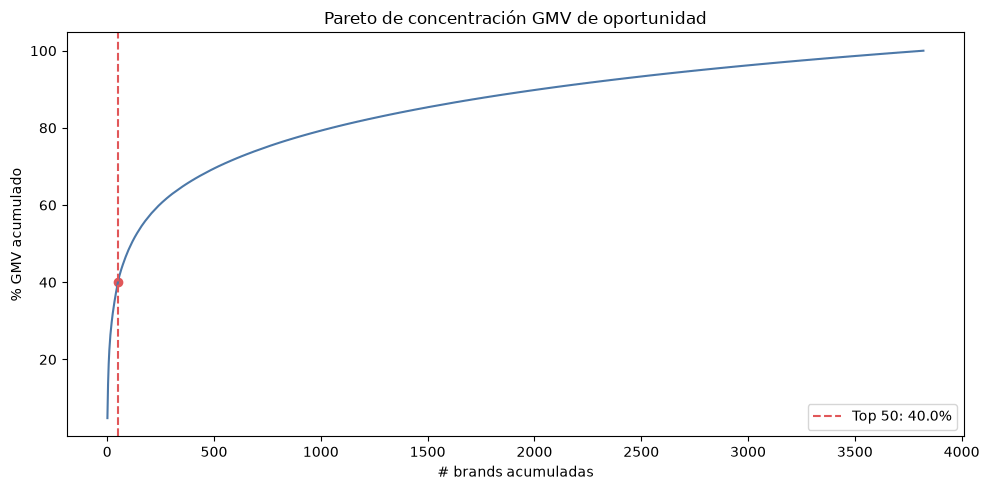

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pareto['rank'], pareto['cumulative_gmv_pct'], color='#4c78a8')
ax.axvline(50, color='#e15759', linestyle='--', label=f"Top 50: {pareto_50.cumulative_gmv_pct:.1f}%")
ax.scatter([50], [pareto_50.cumulative_gmv_pct], color='#e15759')
ax.set_title('Pareto de concentración GMV de oportunidad')
ax.set_xlabel('# brands acumuladas')
ax.set_ylabel('% GMV acumulado')
ax.legend()
plt.tight_layout()
plt.show()

**Conclusión:** El top 50 captura una fracción desproporcionada de la oportunidad, por eso priorizar supera a operar el universo completo sin foco.

## 5. ¿Qué categorías priorizar? BPI por categoría

In [10]:
sql_bpi = '''
SELECT
  category,
  COUNT(*) AS n_brands,
  ROUND(100.0 * SUM(CASE WHEN is_marketplace_today = 1 THEN 1 ELSE 0 END) / COUNT(*), 1) AS bpi_pct,
  ROUND(SUM(gmv_cop_millions_12m), 0) AS gmv_cop_millions_12m
FROM universo
WHERE category NOT IN ('Grandes Superficies')
GROUP BY category
HAVING COUNT(*) >= 5
ORDER BY bpi_pct ASC, gmv_cop_millions_12m DESC
'''
bpi = con.sql(sql_bpi).df()
bpi.head(12)

,category,n_brands,bpi_pct,gmv_cop_millions_12m
0,Vehículos y autopartes,537,6.0,425232.0
1,Viajes y experiencias,16,6.3,27308.0
2,Educación,76,6.6,55762.0
3,Moda,1099,9.2,1141172.0
4,Música y audio,39,10.3,22723.0
5,Hogar,805,11.8,589524.0
6,Salud,267,12.0,155683.0
7,Deportes y aire libre,356,12.4,238610.0
8,Electrodomésticos,389,14.4,338890.0
9,Joyas y accesorios,253,16.6,187123.0


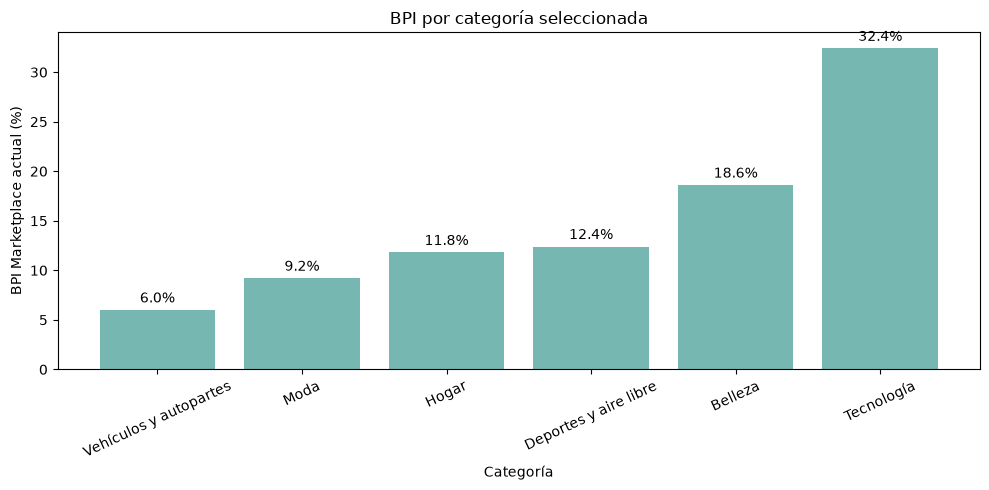

,category,n_brands,bpi_pct,gmv_cop_millions_12m
0,Vehículos y autopartes,537,6.0,425232.0
3,Moda,1099,9.2,1141172.0
5,Hogar,805,11.8,589524.0
7,Deportes y aire libre,356,12.4,238610.0
12,Belleza,393,18.6,308169.0
16,Tecnología,442,32.4,742447.0


In [11]:
plot_cats = bpi[bpi['category'].isin(['Moda','Hogar','Vehículos y autopartes','Tecnología','Belleza','Deportes y aire libre'])].copy()
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_cats['category'], plot_cats['bpi_pct'], color='#76b7b2')
ax.set_title('BPI por categoría seleccionada')
ax.set_xlabel('Categoría')
ax.set_ylabel('BPI Marketplace actual (%)')
ax.tick_params(axis='x', rotation=25)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()
plot_cats[['category','n_brands','bpi_pct','gmv_cop_millions_12m']]

**Conclusión:** Moda, Hogar y Vehículos combinan baja penetración Marketplace relativa con masa de oportunidad; Tecnología aparece más penetrada y se prioriza con más cuidado.